# **1. Introduction to the real-world problem**


# Dataset description

# Data cleaning


In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
# Convertir a DataFrame de Pandas
names = ["Class", "Alcohol", "Malic acid", "Ash", "Alcalinity of ash", "Magnesium","Total phenols", "Flavanoids", "Nonflavanoid phenols", "Proanthocyanins", "Color intensity", "Hue","OD280/OD315 of diluted wines", "Proline"]
df = pd.read_csv('wine.data', names=names)

# Validación de datos y manejo de valores faltantes
# Conteo por columna y suma de todas las columnas.
if df.isnull().sum().sum():
    print("Existen valores faltantes en el dataset.")
else:
    print("No existen valores faltantes en el dataset.")

No existen valores faltantes en el dataset.


In [19]:
df

,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Class                         178 non-null    int64  
 1   Alcohol                       178 non-null    float64
 2   Malic acid                    178 non-null    float64
 3   Ash                           178 non-null    float64
 4   Alcalinity of ash             178 non-null    float64
 5   Magnesium                     178 non-null    int64  
 6   Total phenols                 178 non-null    float64
 7   Flavanoids                    178 non-null    float64
 8   Nonflavanoid phenols          178 non-null    float64
 9   Proanthocyanins               178 non-null    float64
 10  Color intensity               178 non-null    float64
 11  Hue                           178 non-null    float64
 12  OD280/OD315 of diluted wines  178 non-null    float64
 13  Proli

# Exploratory Data Analysis

In [21]:
df.describe()

,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [22]:
df['Class'].value_counts()

,count
Class,
2,71
1,59
3,48


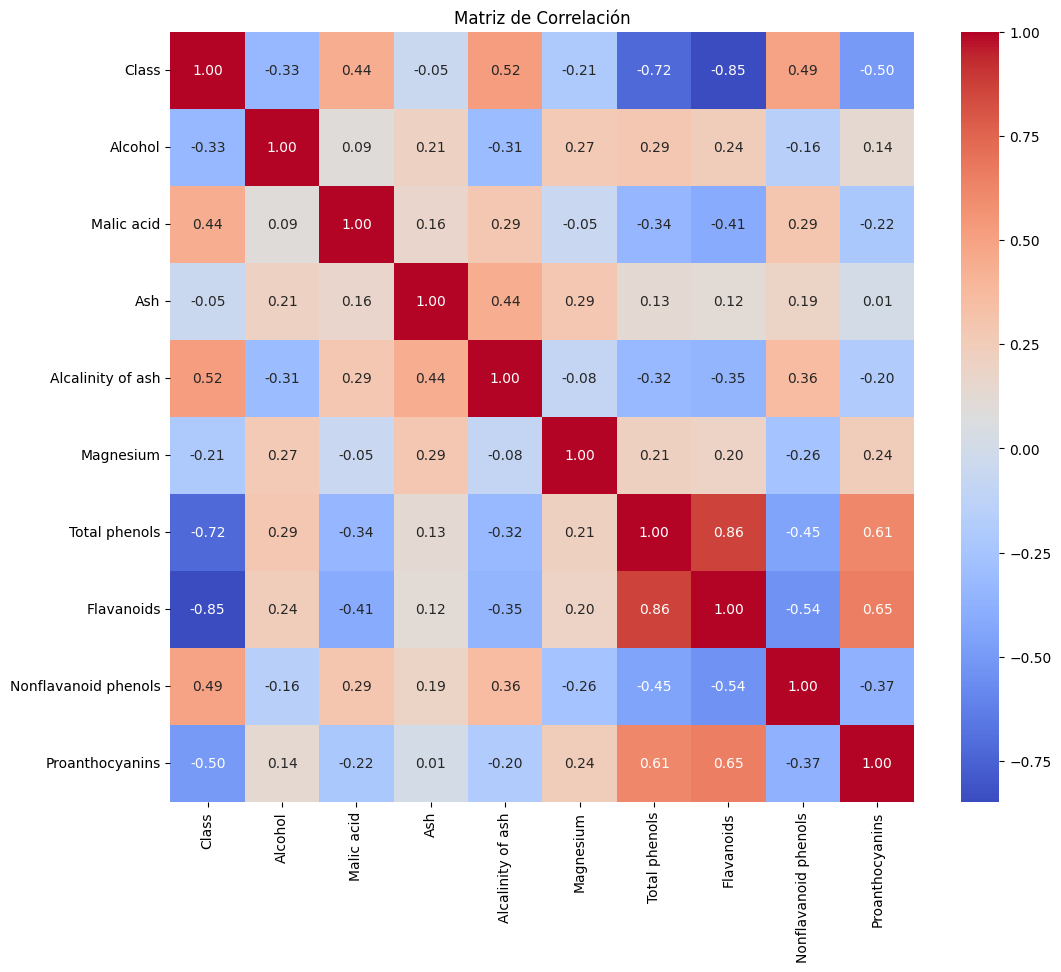

In [23]:
# Análisis de correlación entre las variables para identificar posibles relaciones
correlation_matrix = df.iloc[:, 0:10].corr() # Primeros 10 valores para claridad
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

# **2. Design and Training of the Multilayer Neural Network**

In [34]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.9 MB/s eta 0:00:00


In [35]:
# Importar librerías para la construcción del modelo de red neuronal
import plotly.express as px
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
from tensorflow.keras.models import load_model
from sklearn.decomposition import PCA
import optuna

In [53]:
tf.random.set_seed(4500)
X = df.drop(columns=['Class'])
y = df['Class'] - 1  # Subtract 1 to make labels zero-indexed again
X_train, X_t_v, y_train, y_t_v = train_test_split(X, y, test_size=0.4, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_t_v, y_t_v, test_size=0.5, random_state=42)

In [54]:
# Estandarización de las características para mejorar el rendimiento del modelo
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

In [55]:
def objective(trial):
    # --- ESPACIO DE BÚSQUEDA ---
    lr = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    num_layers = trial.suggest_int("num_layers", 2, 4)

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(13,)))

    # Agregar capas ocultas según la sugerencia de Optuna
    for i in range(num_layers):
        units = trial.suggest_int(f"units_l{i}", 16, 512) # Requisito: 16 a 512
        model.add(tf.keras.layers.Dense(units, activation='relu'))

    # Capa de salida (3 clases)
    model.add(tf.keras.layers.Dense(3, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # --- EARLY STOPPING (Requisito: 5pts) ---
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=100,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    # Retornamos el mejor accuracy de validación
    return max(history.history['val_accuracy'])

In [56]:
# 3. Ejecución de la Optimización
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler())
study.optimize(objective, n_trials=5)

# 4. Guardar y evaluar el mejor modelo (Requisito: 5pts Save + 10pts Metrics)
print(f"Mejor configuración: {study.best_params}")

[I 2026-03-24 19:21:57,977] A new study created in memory with name: no-name-8b03b350-be08-4972-accf-5063ff2befe7
[I 2026-03-24 19:22:13,216] Trial 0 finished with value: 1.0 and parameters: {'learning_rate': 0.00026083561568703034, 'batch_size': 16, 'num_layers': 3, 'units_l0': 193, 'units_l1': 373, 'units_l2': 67}. Best is trial 0 with value: 1.0.
[I 2026-03-24 19:22:17,088] Trial 1 finished with value: 0.9722222089767456 and parameters: {'learning_rate': 0.0028878358239411567, 'batch_size': 16, 'num_layers': 3, 'units_l0': 24, 'units_l1': 40, 'units_l2': 184}. Best is trial 0 with value: 1.0.
[I 2026-03-24 19:22:30,484] Trial 2 finished with value: 1.0 and parameters: {'learning_rate': 0.0002755234387104947, 'batch_size': 16, 'num_layers': 2, 'units_l0': 462, 'units_l1': 93}. Best is trial 0 with value: 1.0.
[I 2026-03-24 19:22:35,209] Trial 3 finished with value: 1.0 and parameters: {'learning_rate': 0.0053348273339264085, 'batch_size': 16, 'num_layers': 4, 'units_l0': 210, 'units_

Mejor configuración: {'learning_rate': 0.00026083561568703034, 'batch_size': 16, 'num_layers': 3, 'units_l0': 193, 'units_l1': 373, 'units_l2': 67}


In [ ]:
model = tf.keras.models.Sequential([
tf.keras.layers.Input(shape=(13,)),
tf.keras.layers.Dense(128, activation='relu'),
tf.keras.layers.Dense(64, activation='relu'),
tf.keras.layers.Dense(3, activation='softmax')
])